# IntZ Example 3: Tier-1 Kinematics
**EPS Research IntZ Kinematic Corpus v1.0**

Explore circular velocity, velocity dispersion, and V/sigma for the 166 Tier-1 KROSS galaxies.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load IntZ corpus
with open('/home/david/Documents/RAG Project/Z=2 RAG/Zenodo/intz_corpus_v1b.json') as f:
    data = json.load(f)
galaxies = data['galaxies']
print(f"Loaded {len(galaxies)} galaxies")

Loaded 1292 galaxies


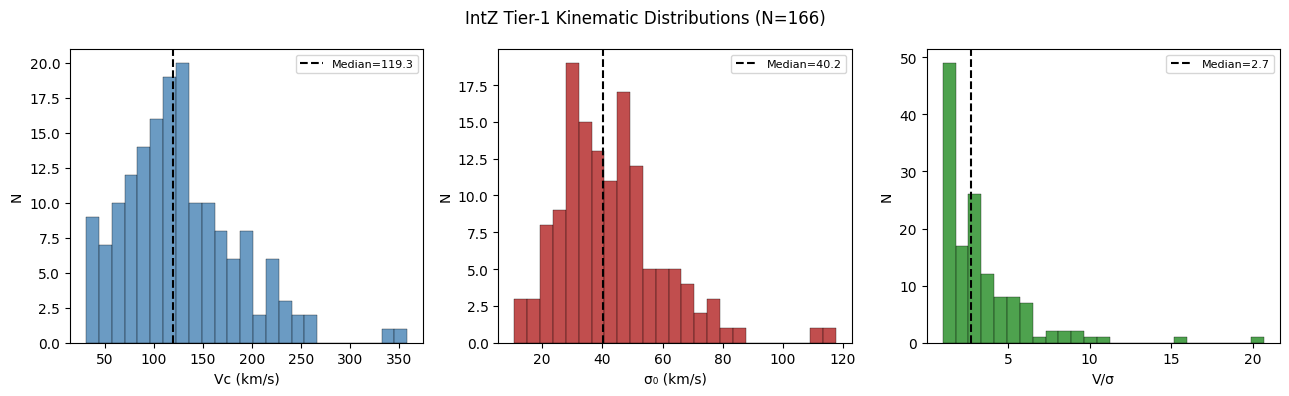

In [2]:
t1 = [g for g in galaxies if g['metadata']['quality_tier']==1]
vc  = [g['kinematics']['Vc_kms'] for g in t1
       if g['kinematics']['Vc_kms']]
s0  = [g['kinematics']['sigma0_kms'] for g in t1
       if g['kinematics']['sigma0_kms'] and g['kinematics']['sigma0_kms'] < 200]
vos = [g['kinematics']['v_over_sigma'] for g in t1
       if g['kinematics']['v_over_sigma'] and g['kinematics']['v_over_sigma'] < 30]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, vals, label, color in zip(
    axes,
    [vc, s0, vos],
    ['Vc (km/s)', 'σ₀ (km/s)', 'V/σ'],
    ['steelblue', 'firebrick', 'forestgreen']
):
    ax.hist(vals, bins=25, color=color, alpha=0.8, edgecolor='k', lw=0.3)
    ax.axvline(np.median(vals), color='black', ls='--', lw=1.5,
               label=f'Median={np.median(vals):.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('N')
    ax.legend(fontsize=8)
fig.suptitle('IntZ Tier-1 Kinematic Distributions (N=166)', fontsize=12)
plt.tight_layout()
plt.savefig('intz_nb3_tier1_kin.png', dpi=120)
plt.show()